Using Colab cache for faster access to the 'gtd' dataset.
Dataset path:
/kaggle/input/gtd

CSV files found:
['globalterrorismdb_0718dist.csv']

Dataset Loaded Successfully

First 5 Records:
        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  197000000001   1970       7     2        NaN         0        NaN       58   
1  197000000002   1970       0     0        NaN         0        NaN      130   
2  197001000001   1970       1     0        NaN         0        NaN      160   
3  197001000002   1970       1     0        NaN         0        NaN       78   
4  197001000003   1970       1     0        NaN         0        NaN      101   

          country_txt  region  ... addnotes scite1 scite2  scite3  dbsource  \
0  Dominican Republic       2  ...      NaN    NaN    NaN     NaN      PGIS   
1              Mexico       1  ...      NaN    NaN    NaN     NaN      PGIS   
2         Philippines       5  ...      NaN    NaN    NaN     NaN      PGIS   
3      

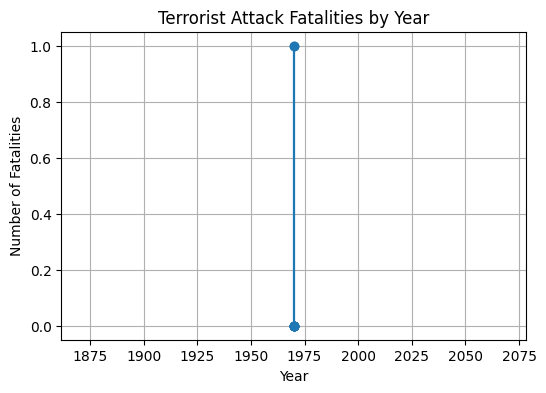

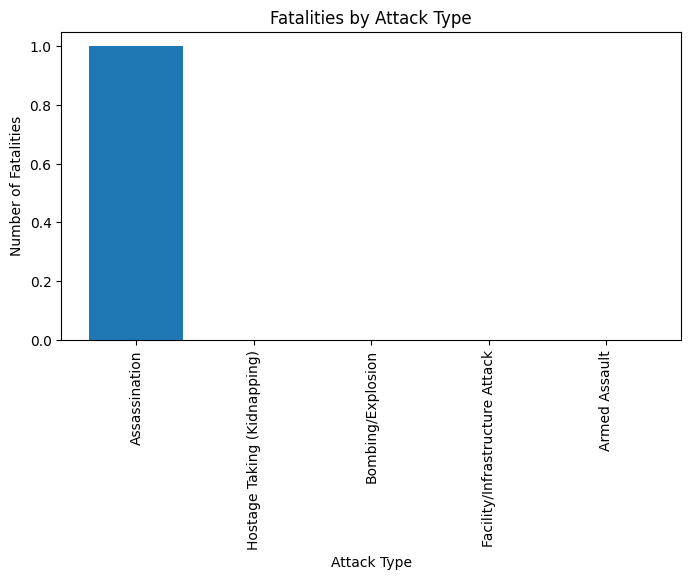

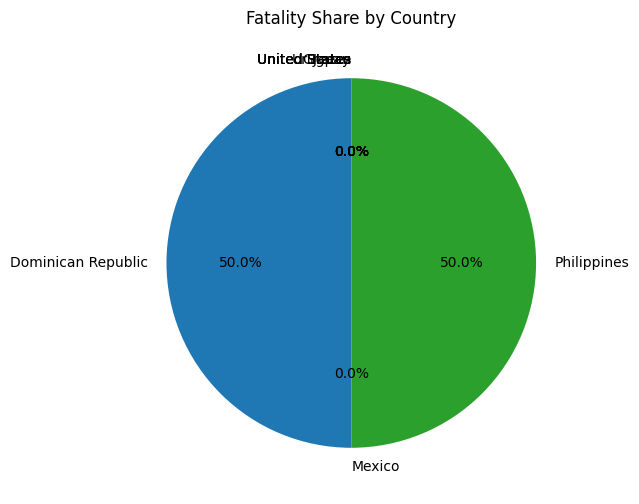

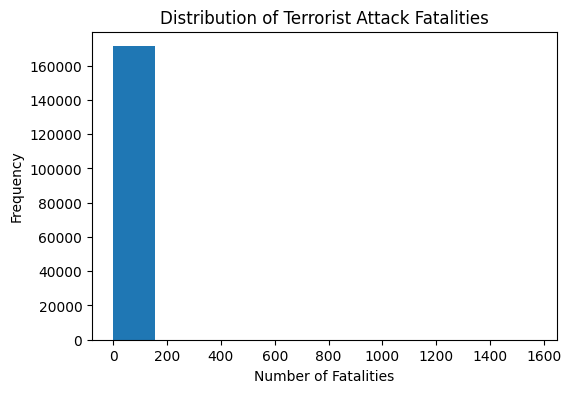

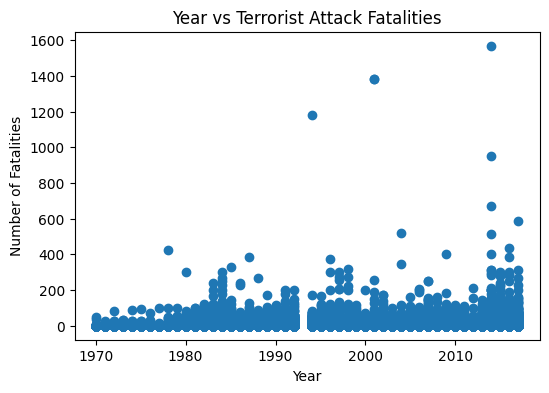

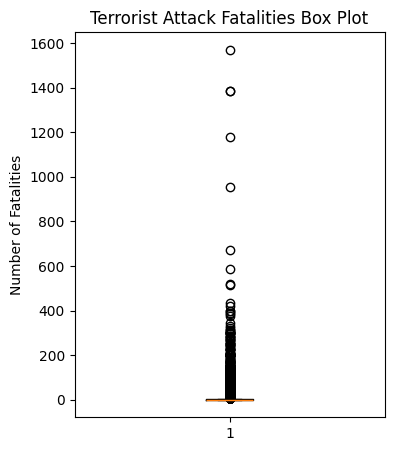


DATA VISUALIZATION COMPLETED
Total Attacks: 181691
Total Fatalities: 411868.0
Number of Countries: 205
Number of Attack Types: 9


In [1]:
# ============================================================
# DATA VISUALIZATION - GLOBAL TERRORISM DATABASE
# ============================================================

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# LOAD DATASET FROM KAGGLE
# ============================================================

path = kagglehub.dataset_download("START-UMD/gtd")

print("Dataset path:")
print(path)

# Find CSV file automatically
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

print("\nCSV files found:")
print(csv_files)

csv_file = csv_files[0]

# Load dataset
df = pd.read_csv(
    os.path.join(path, csv_file),
    encoding="latin1",
    low_memory=False
)

print("\nDataset Loaded Successfully")

# ============================================================
# DISPLAY DATA
# ============================================================

print("\nFirst 5 Records:")
print(df.head())

# ============================================================
# CREATE A SMALL DATAFRAME FOR VISUALIZATION
# ============================================================

# Select required columns
plot_df = df[
    ["iyear", "country_txt", "attacktype1_txt", "nkill"]
].copy()

# Replace missing fatalities with 0
plot_df["nkill"] = plot_df["nkill"].fillna(0)

# Take first 10 records for simple visualization
plot_df = plot_df.head(10)

print("\nData Used for Visualization:")
print(plot_df)

# ============================================================
# 1. LINE PLOT
# Year vs Fatalities
# ============================================================

plt.figure(figsize=(6,4))

plt.plot(
    plot_df["iyear"],
    plot_df["nkill"],
    marker="o"
)

plt.title("Terrorist Attack Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")

plt.grid(True)

plt.show()

# ============================================================
# 2. BAR CHART
# Attack Type
# ============================================================

plt.figure(figsize=(8,4))

plt.bar(
    plot_df["attacktype1_txt"],
    plot_df["nkill"]
)

plt.title("Fatalities by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Number of Fatalities")

plt.xticks(rotation=90)

plt.show()

# ============================================================
# 3. PIE CHART
# Fatality Share
# ============================================================

plt.figure(figsize=(6,6))

plt.pie(
    plot_df["nkill"],
    labels=plot_df["country_txt"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Fatality Share by Country")

plt.show()

# ============================================================
# 4. HISTOGRAM
# Fatality Distribution
# ============================================================

plt.figure(figsize=(6,4))

plt.hist(
    df["nkill"].dropna(),
    bins=10
)

plt.title("Distribution of Terrorist Attack Fatalities")
plt.xlabel("Number of Fatalities")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# 5. SCATTER PLOT
# Year vs Fatalities
# ============================================================

plt.figure(figsize=(6,4))

plt.scatter(
    df["iyear"],
    df["nkill"].fillna(0)
)

plt.title("Year vs Terrorist Attack Fatalities")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")

plt.show()

# ============================================================
# 6. BOX PLOT
# Fatalities
# ============================================================

plt.figure(figsize=(4,5))

plt.boxplot(
    df["nkill"].dropna()
)

plt.title("Terrorist Attack Fatalities Box Plot")
plt.ylabel("Number of Fatalities")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n======================================")
print("DATA VISUALIZATION COMPLETED")
print("======================================")

print("Total Attacks:", len(df))
print("Total Fatalities:", df["nkill"].sum())
print("Number of Countries:", df["country_txt"].nunique())
print("Number of Attack Types:", df["attacktype1_txt"].nunique())

print("======================================")